In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity
import functionsTP as myfunc
import time

In [2]:
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape).astype(np.uint8)
    noisy_image = cv2.add(image, noise)
    return noisy_image

## Bilateral filter Implementation 

Height: 500, Width: 500, Channels: 1


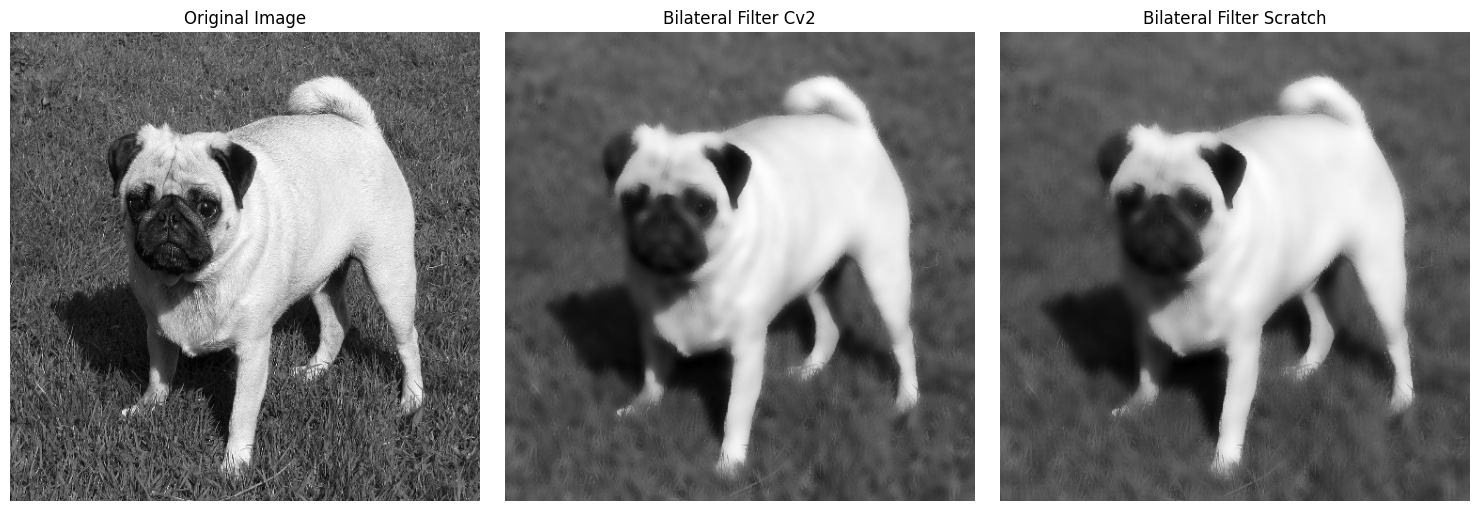

In [ ]:
image_path = 'images/Image2.jpg'
L_image = cv2.imread(image_path)
L_image = cv2.resize(L_image, (500,500))
image = cv2.cvtColor(L_image, cv2.COLOR_BGR2GRAY)

print(f"Height: {image.shape[0]}, Width: {image.shape[1]}, Channels: {image.shape[2] if len(image.shape) > 2 else 1}")

filtered_image_OpenCV = cv2.bilateralFilter(image, 15, 75.0, 75.0)
filtered_image_Scratch = myfunc.bilateral_filter_scratch(image, 15, 75.0, 75.0)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  

# Plot Original
axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')

# Plot filtro do OpenCV
axs[1].imshow(filtered_image_OpenCV, cmap='gray')
axs[1].set_title('Bilateral Filter Cv2')
axs[1].axis('off')

# Plot filtro próprio
axs[2].imshow(filtered_image_Scratch, cmap='gray')
axs[2].set_title('Bilateral Filter Scratch')
axs[2].axis('off')

plt.tight_layout()
plt.show()

Height: 500, Width: 500, Channels: 1


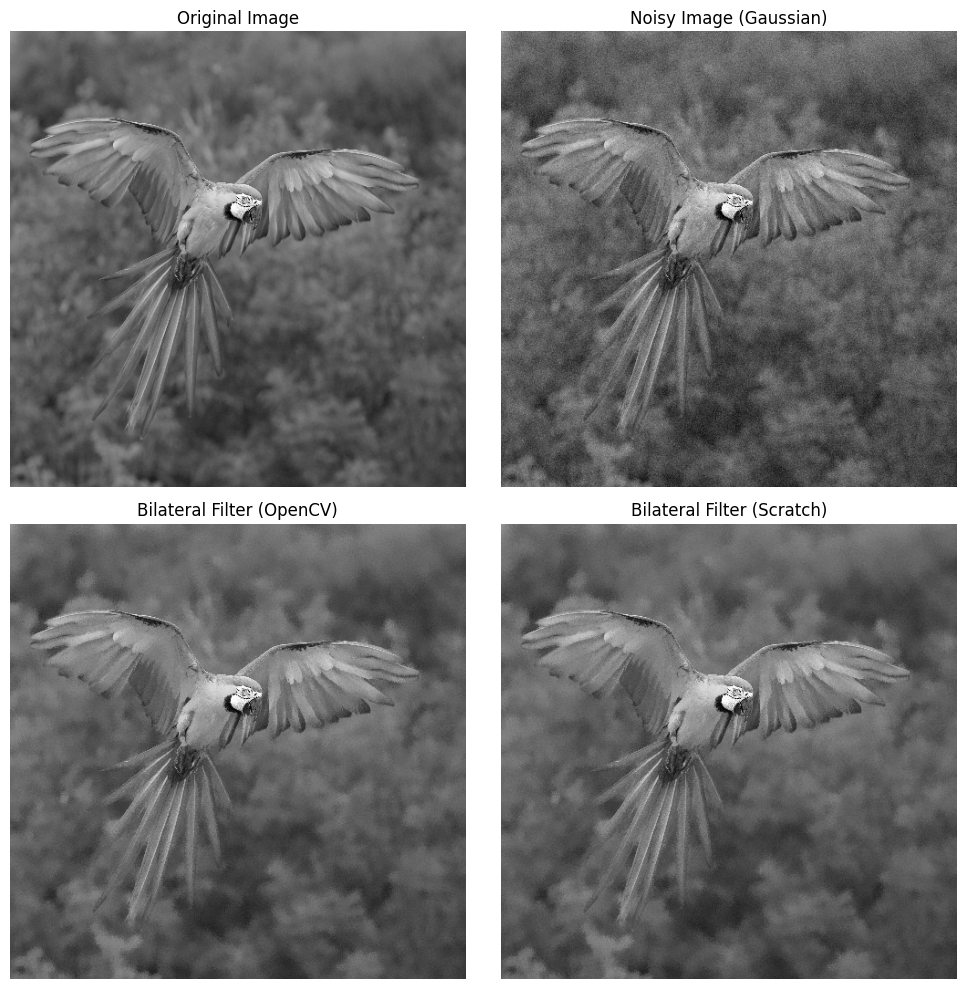

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'images/Image5.jpg'
L_image = cv2.imread(image_path)
L_image = cv2.resize(L_image, (500, 500))
image = cv2.cvtColor(L_image, cv2.COLOR_BGR2GRAY)

print(f"Height: {image.shape[0]}, Width: {image.shape[1]}, Channels: 1")

# -------------------------------------------------
# Add small Gaussian noise
# -------------------------------------------------
mean = 0
sigma = 10  # small noise level
gaussian_noise = np.random.normal(mean, sigma, image.shape)

noisy_image = image.astype(np.float32) + gaussian_noise
noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)

# -------------------------------------------------
# Apply filters to noisy image
# -------------------------------------------------
filtered_image_OpenCV = cv2.bilateralFilter(noisy_image, 15, 15.0, 15.0)
filtered_image_Scratch = myfunc.bilateral_filter_scratch(noisy_image, 15, 15.0, 15.0)

# -------------------------------------------------
# Plot 2x2 grid
# -------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Original image
axs[0, 0].imshow(image, cmap='gray')
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

# Noisy image
axs[0, 1].imshow(noisy_image, cmap='gray')
axs[0, 1].set_title('Noisy Image (Gaussian)')
axs[0, 1].axis('off')

# OpenCV Bilateral Filter
axs[1, 0].imshow(filtered_image_OpenCV, cmap='gray')
axs[1, 0].set_title('Bilateral Filter (OpenCV)')
axs[1, 0].axis('off')

# Scratch Bilateral Filter
axs[1, 1].imshow(filtered_image_Scratch, cmap='gray')
axs[1, 1].set_title('Bilateral Filter (Scratch)')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()


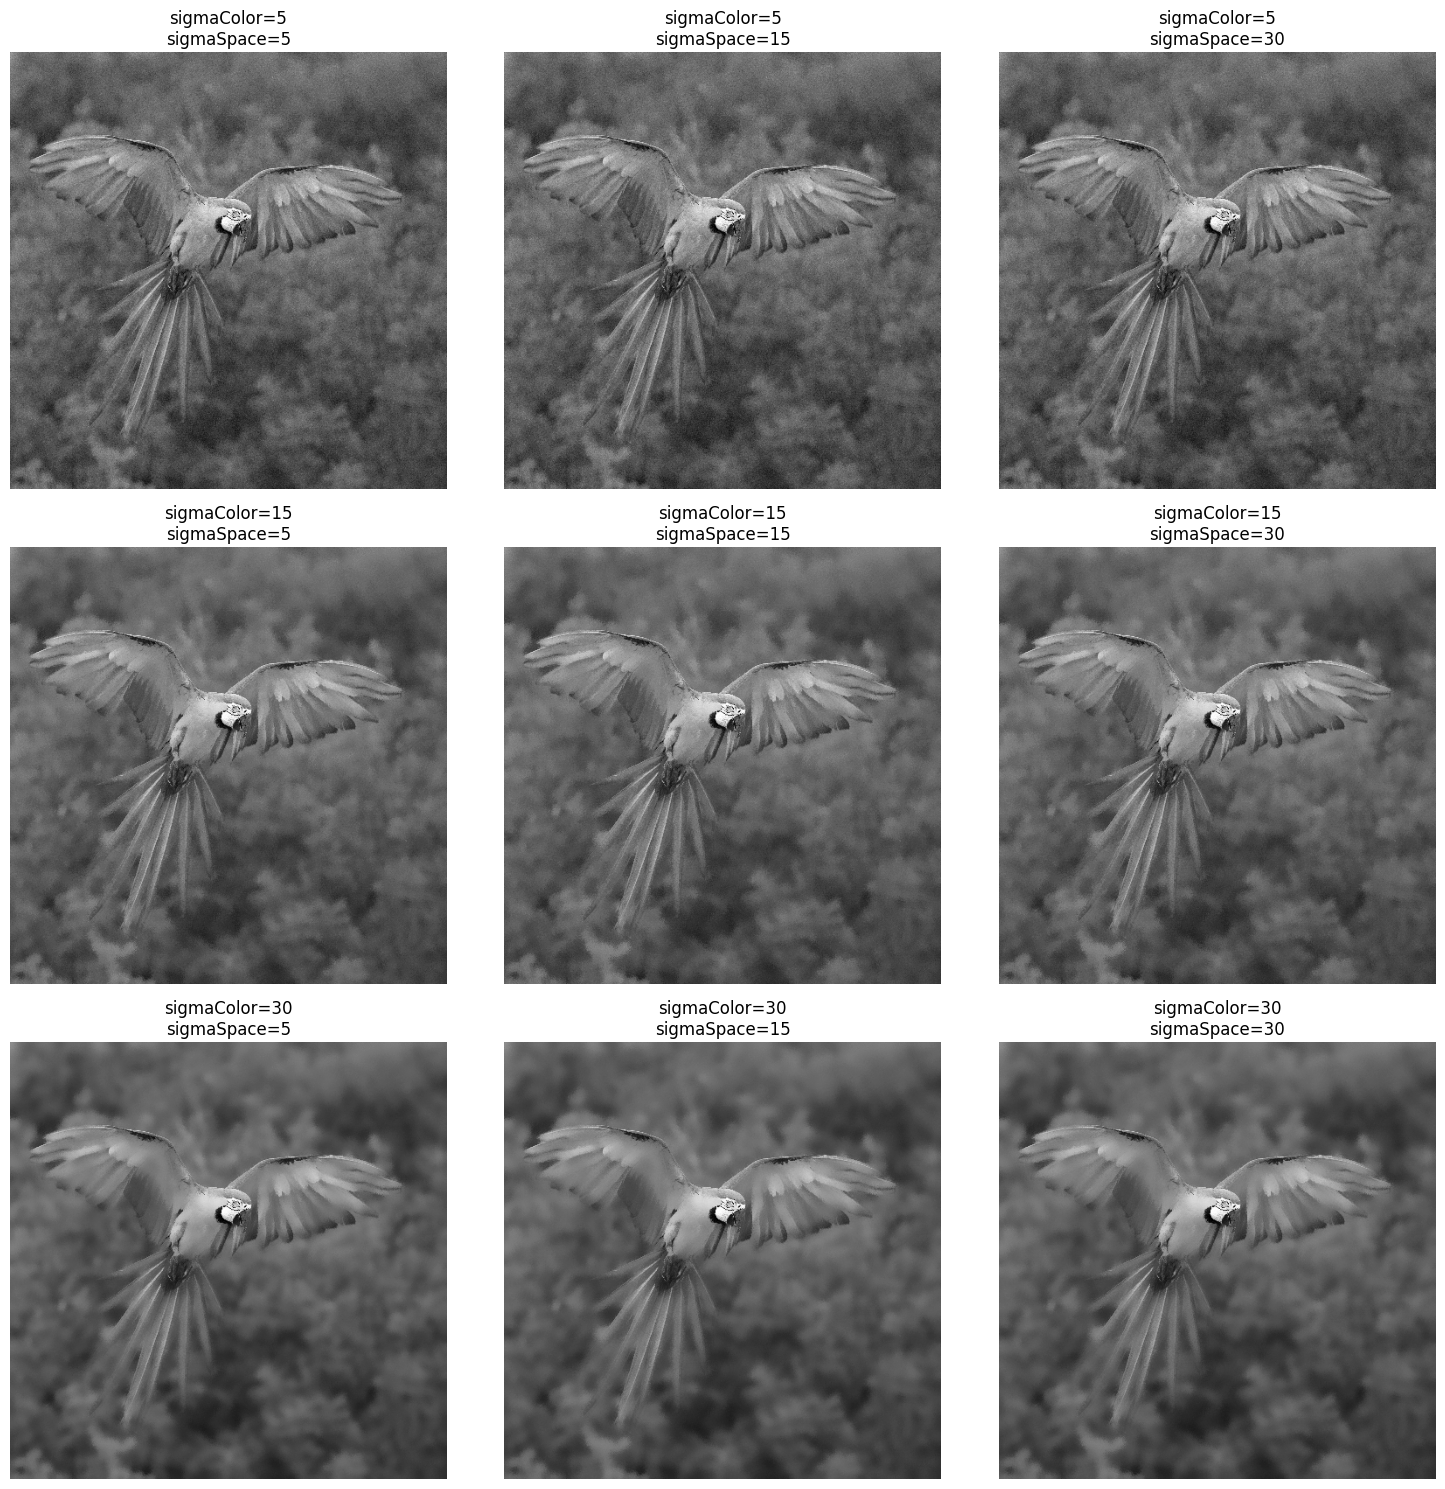

In [4]:
sigma_colors = [5, 15, 30]
sigma_spaces = [5, 15, 30]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, sigma_color in enumerate(sigma_colors):
    for j, sigma_space in enumerate(sigma_spaces):
        filtered = cv2.bilateralFilter(noisy_image, d=15, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'sigmaColor={sigma_color}\nsigmaSpace={sigma_space}')
        ax.axis('off')

plt.tight_layout()
plt.show()

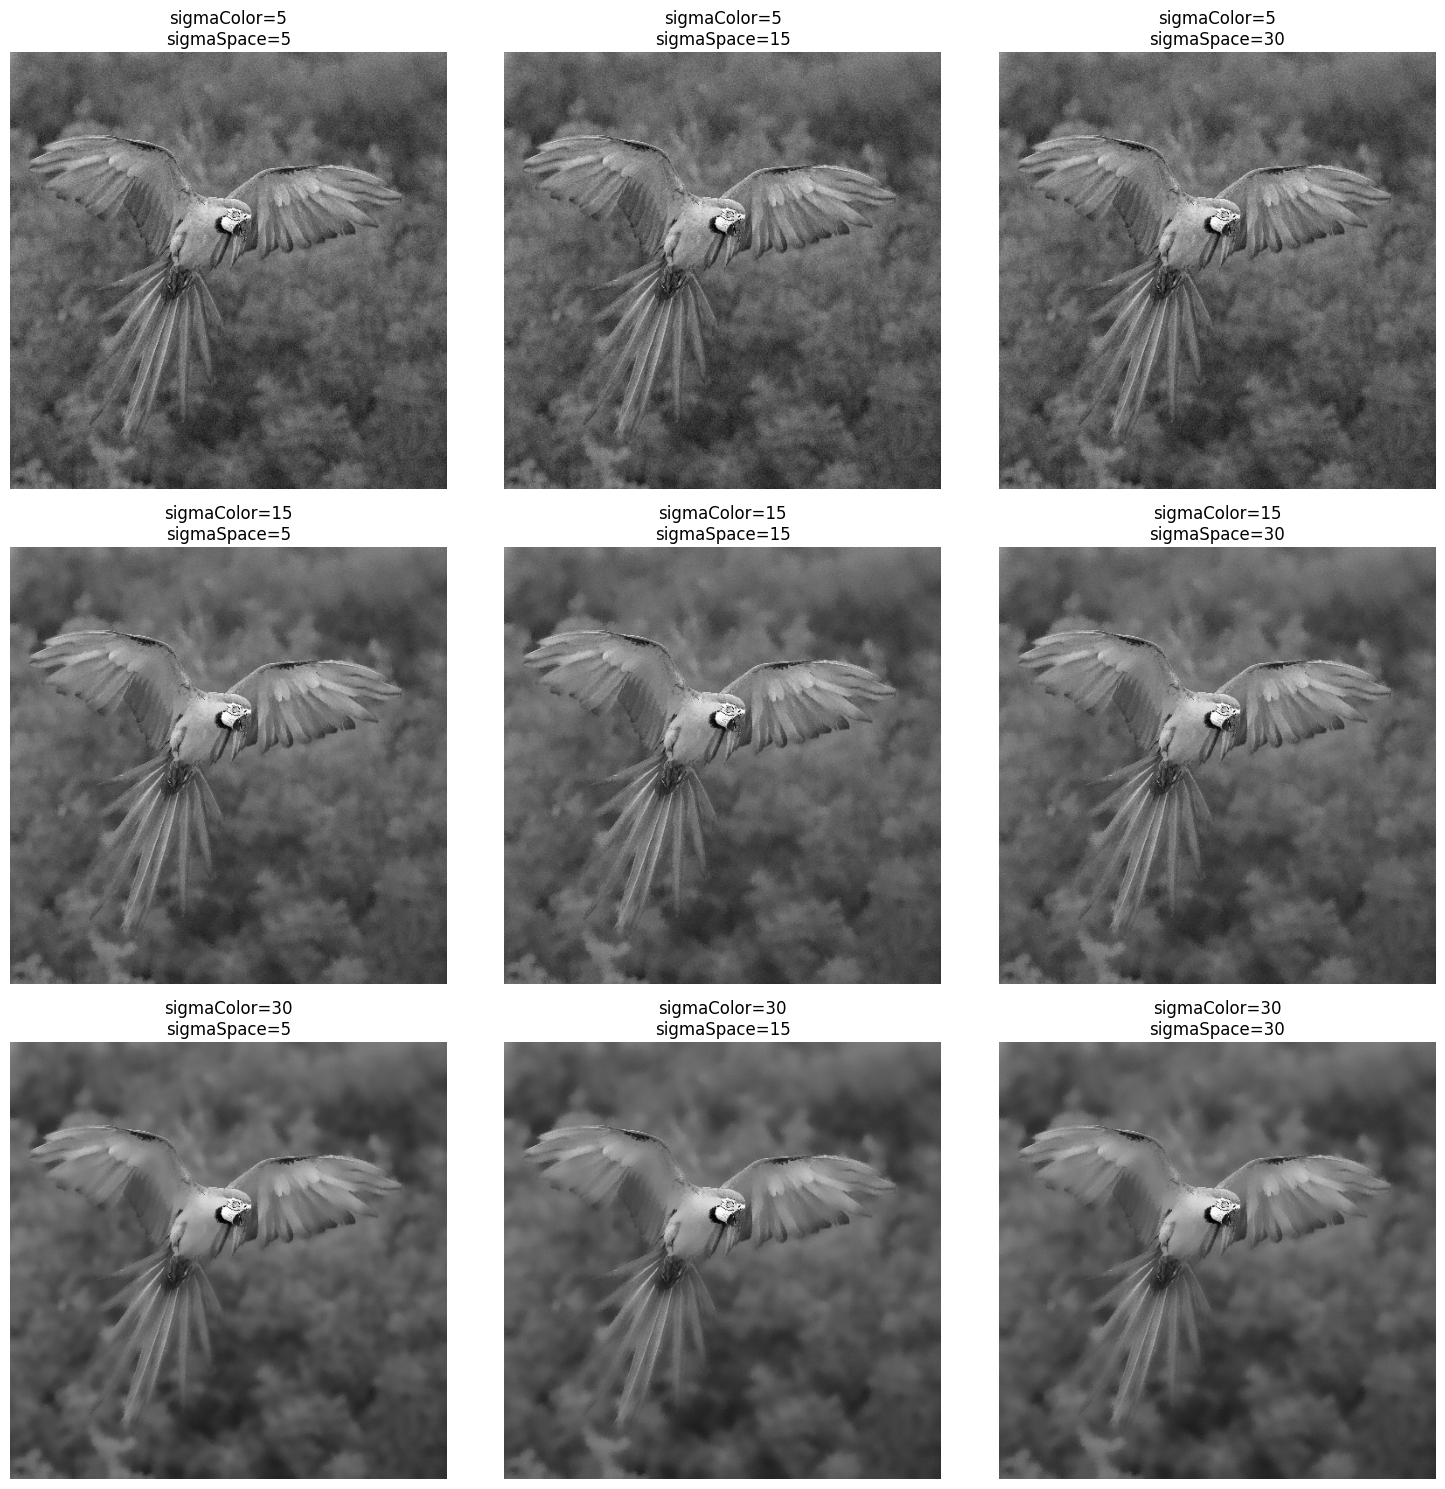

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for i, sigma_color in enumerate(sigma_colors):
    for j, sigma_space in enumerate(sigma_spaces):
        filtered = myfunc.bilateral_filter_scratch(noisy_image, 15, sigma_color, sigma_space)
        
        ax = axs[i, j]
        ax.imshow(filtered, cmap='gray')
        ax.set_title(f'sigmaColor={sigma_color}\nsigmaSpace={sigma_space}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
def compare_filters(noisy_image, image, d, sigma_values):
    results = {
        'bilateral': [],
        'bilateral_cv2': [],
        'gaussian': []
    }

    for sigma in sigma_values:
        # Bilateral filter (sigmaColor = sigmaSpace = sigma)
        filtered_bilat = myfunc.bilateral_filter_scratch(noisy_image, d, sigma, sigma)
        mse_bilat = mean_squared_error(image, filtered_bilat)
        psnr_bilat = peak_signal_noise_ratio(image, filtered_bilat, data_range=255)
        ssim_bilat = structural_similarity(image, filtered_bilat, data_range=255)

        results['bilateral'].append({
            'sigma': sigma,
            'mse': mse_bilat,
            'psnr': psnr_bilat,
            'ssim': ssim_bilat
        })
        
        # Bilateral filter (sigmaColor = sigmaSpace = sigma)
        filtered_bilat = cv2.bilateralFilter(noisy_image, d, sigma, sigma)
        mse_bilat = mean_squared_error(image, filtered_bilat)
        psnr_bilat = peak_signal_noise_ratio(image, filtered_bilat, data_range=255)
        ssim_bilat = structural_similarity(image, filtered_bilat, data_range=255)

        results['bilateral_cv2'].append({
            'sigma': sigma,
            'mse': mse_bilat,
            'psnr': psnr_bilat,
            'ssim': ssim_bilat
        })

        # Gaussian filter
        # ksize deve ser ímpar e igual a d
        filtered_gauss = cv2.GaussianBlur(noisy_image, (d, d), sigmaX=sigma)
        mse_gauss = mean_squared_error(image, filtered_gauss)
        psnr_gauss = peak_signal_noise_ratio(image, filtered_gauss, data_range=255)
        ssim_gauss = structural_similarity(image, filtered_gauss, data_range=255)

        results['gaussian'].append({
            'sigma': sigma,
            'mse': mse_gauss,
            'psnr': psnr_gauss,
            'ssim': ssim_gauss
        })

    return results
        

In [8]:
d = 15
sigma_values = [5, 10, 15, 20, 30, 50]

results = compare_filters(noisy_image, image, d, sigma_values)

# Mostrar resultados
print("Comparação Bilateral x Gaussian para diferentes valores de sigma (d=9):\n")

print("Bilateral Filter:")
for r in results['bilateral']:
    print(f"sigma={r['sigma']:>5} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")
    
print("\nBilateral Filter cv2:")
for r in results['bilateral_cv2']:
    print(f"sigma={r['sigma']:>5} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")

print("\nGaussian Filter:")
for r in results['gaussian']:
    print(f"sigma={r['sigma']:>5} | MSE={r['mse']:.2f} | PSNR={r['psnr']:.2f} | SSIM={r['ssim']:.4f}")



Comparação Bilateral x Gaussian para diferentes valores de sigma (d=9):

Bilateral Filter:
sigma=    5 | MSE=78.55 | PSNR=29.18 | SSIM=0.6324
sigma=   10 | MSE=48.69 | PSNR=31.26 | SSIM=0.7364
sigma=   15 | MSE=36.02 | PSNR=32.56 | SSIM=0.8117
sigma=   20 | MSE=34.78 | PSNR=32.72 | SSIM=0.8424
sigma=   30 | MSE=45.14 | PSNR=31.58 | SSIM=0.8392
sigma=   50 | MSE=71.53 | PSNR=29.59 | SSIM=0.7948

Bilateral Filter cv2:
sigma=    5 | MSE=78.10 | PSNR=29.20 | SSIM=0.6341
sigma=   10 | MSE=46.55 | PSNR=31.45 | SSIM=0.7457
sigma=   15 | MSE=32.54 | PSNR=33.01 | SSIM=0.8257
sigma=   20 | MSE=29.80 | PSNR=33.39 | SSIM=0.8591
sigma=   30 | MSE=36.66 | PSNR=32.49 | SSIM=0.8612
sigma=   50 | MSE=57.12 | PSNR=30.56 | SSIM=0.8261

Gaussian Filter:
sigma=    5 | MSE=109.29 | PSNR=27.75 | SSIM=0.7642
sigma=   10 | MSE=127.13 | PSNR=27.09 | SSIM=0.7306
sigma=   15 | MSE=130.18 | PSNR=26.99 | SSIM=0.7250
sigma=   20 | MSE=131.44 | PSNR=26.94 | SSIM=0.7228
sigma=   30 | MSE=132.86 | PSNR=26.90 | SSIM=0.7

## Isotropic diffusion

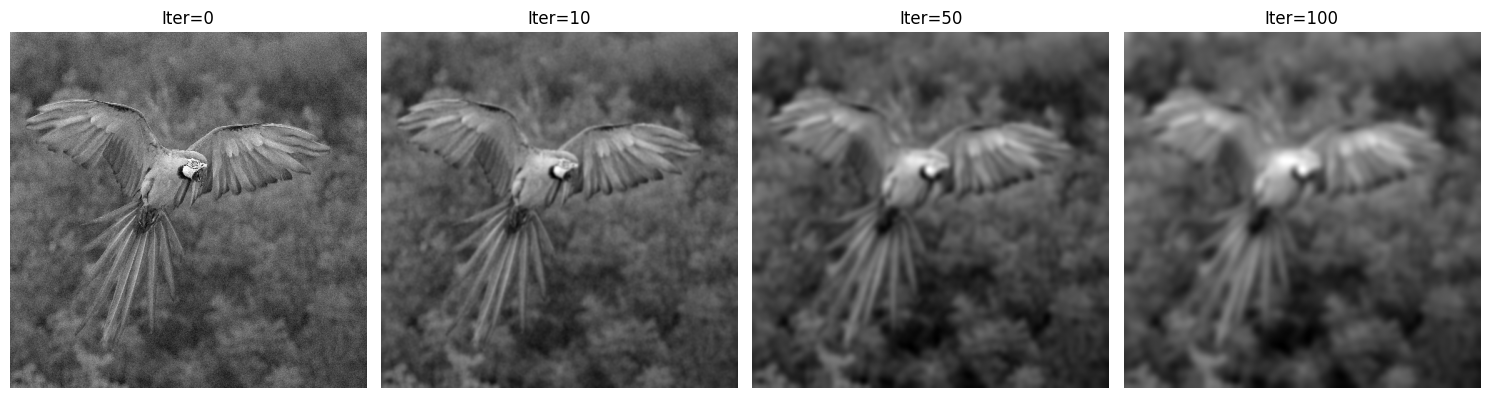

In [9]:
n_iters = [0, 10, 50, 100]

fig, axs = plt.subplots(1, 4, figsize=(15, 15))

for i, n_iter in enumerate(n_iters):
    filtered = myfunc.isotropic_diffusion(noisy_image, n_iter)
    
    ax = axs[i]
    ax.imshow(filtered, cmap='gray')
    ax.set_title(f'Iter={n_iter}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Anisotropic diffusion

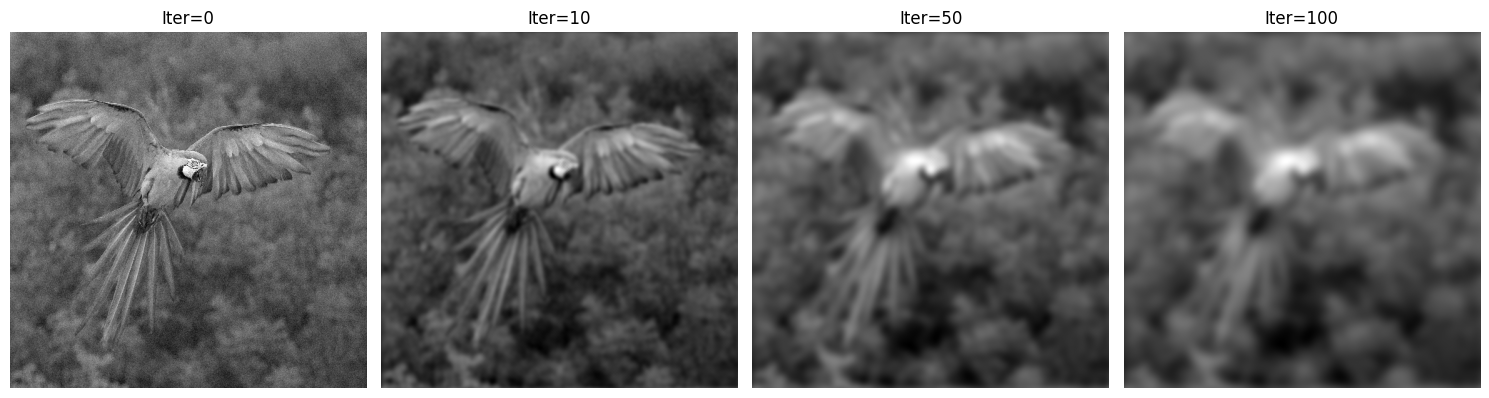

In [10]:
n_iters = [0, 10, 50, 100]

fig, axs = plt.subplots(1, 4, figsize=(15, 15))

for i, n_iter in enumerate(n_iters):
    filtered = myfunc.anisotropic_diffusion(noisy_image, n_iter)
    
    ax = axs[i]
    ax.imshow(filtered, cmap='gray')
    ax.set_title(f'Iter={n_iter}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Deep Image Prior (DIP)